# Lab 5: OFDM — высокоскоростная передача данных

**Цель**: построить OFDM-модем и показать, как параллельные ортогональные несущие дают кратный рост скорости по сравнению с FSK.

**Что исследуем**:
1. QAM-созвездия (QPSK / 16-QAM / 64-QAM) — сколько бит несёт символ
2. Ортогональность несущих OFDM (почему они не мешают друг другу)
3. Структура OFDM-кадра: Schmidl-Cox преамбула + циклический префикс (CP)
4. Пилот-сигналы и эквализация канала
5. BER vs SNR для разных порядков QAM
6. Итоговое сравнение OFDM vs FSK (скорость против надёжности)

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('common'))
import numpy as np
import matplotlib.pyplot as plt
import modem_lib as m
plt.rcParams['figure.dpi'] = 100
FS = m.FS
print(f'Библиотека загружена. FS = {FS} Гц')

Библиотека загружена. FS = 48000 Гц


## 5.1 QAM-созвездия
QAM кодирует несколько бит в одном комплексном символе (амплитуда+фаза).
- **QPSK** = 2 бита/символ — точки далеко друг от друга, устойчиво к шуму
- **16-QAM** = 4 бита/символ — плотнее, нужен SNR выше
- **64-QAM** = 6 бит/символ — ещё плотнее, ещё требовательнее

Чем больше бит на символ — тем выше скорость, но тем ближе точки и тем легче шуму «перебросить» символ в соседнюю.

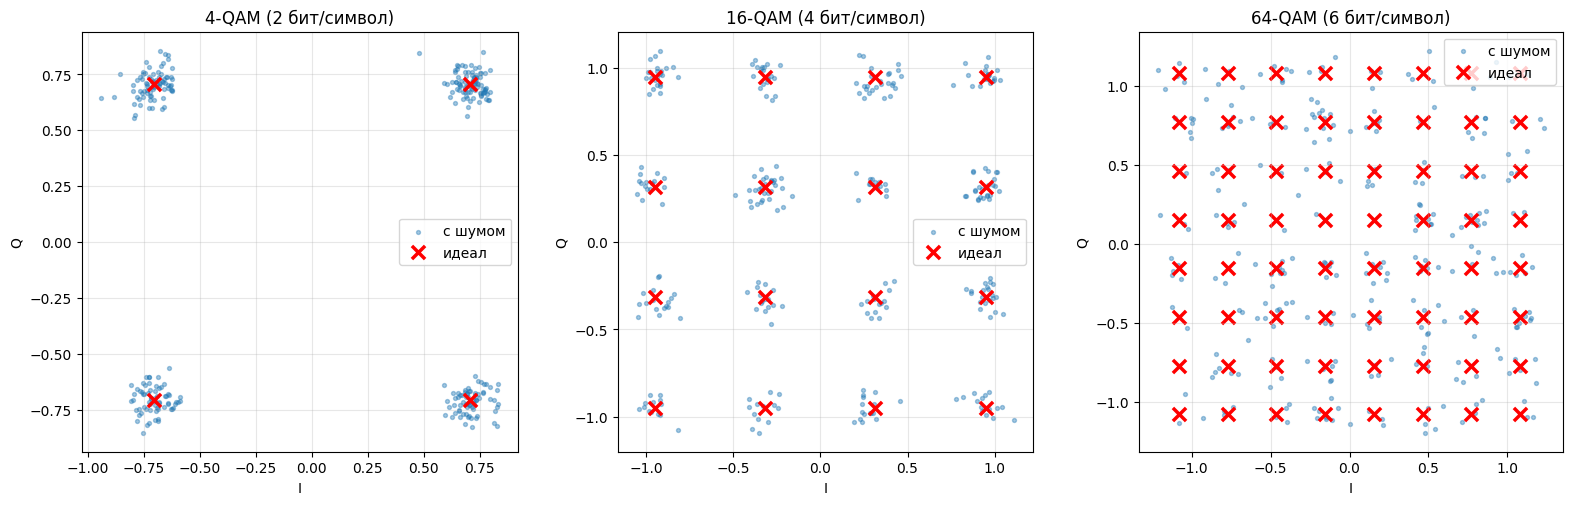

Gray-кодирование: соседние точки отличаются ровно 1 битом -> ошибка в соседа стоит всего 1 бит.


In [2]:
rng = np.random.default_rng(0)
orders = [4, 16, 64]
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, order in zip(axes, orders):
    bps = int(np.log2(order))
    bits = ''.join(str(b) for b in rng.integers(0, 2, bps*300))
    syms = m.qam_map(bits, order)
    # добавим немного шума чтобы увидеть «облака»
    noisy = syms + 0.06*(rng.standard_normal(len(syms)) + 1j*rng.standard_normal(len(syms)))
    ax.scatter(noisy.real, noisy.imag, s=8, alpha=0.4, label='с шумом')
    # идеальные точки
    ideal = m.qam_map(''.join(format(i, f'0{bps}b') for i in range(order)), order)
    ax.scatter(ideal.real, ideal.imag, s=90, c='red', marker='x', linewidths=2.5, label='идеал')
    ax.set_title(f'{order}-QAM ({bps} бит/символ)')
    ax.set_xlabel('I'); ax.set_ylabel('Q'); ax.grid(alpha=0.3); ax.legend(); ax.set_aspect('equal')
plt.tight_layout(); plt.show()
print('Gray-кодирование: соседние точки отличаются ровно 1 битом -> ошибка в соседа стоит всего 1 бит.')

## 5.2 Ортогональность несущих
OFDM ставит несущие на частоты, кратные 1/T (T — длина символа). На интервале символа каждая пара несущих ортогональна: интеграл их произведения = 0. Поэтому FFT идеально разделяет их, хотя спектры перекрываются!

FFT=128, CP=32, данных-несущих=42, пилотов=6
Бит/символ: 84, длит. символа: 3.33 мс, битрейт: 25200 бит/с


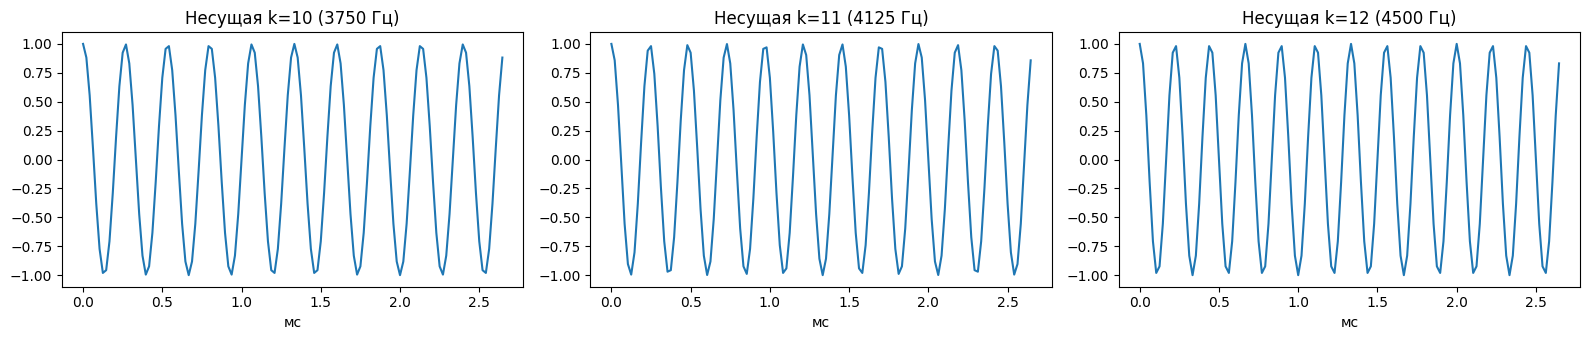

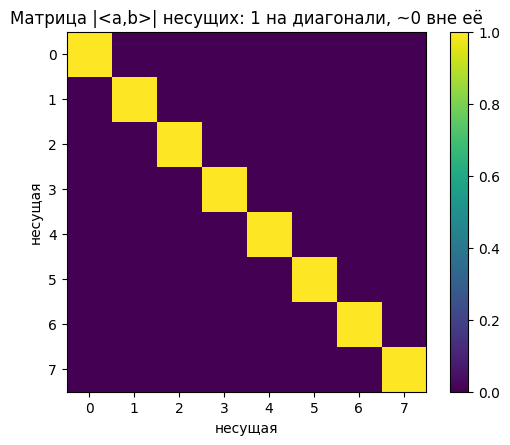

Диагональ = 1, остальное ~0: несущие ортогональны, FFT разделяет их без потерь.


In [3]:
cfg = m.OFDMConfig(fft_size=128, cp_len=32, num_data_carriers=48, carrier_start=2, qam_order=4)
print(f'FFT={cfg.fft_size}, CP={cfg.cp_len}, данных-несущих={len(cfg.data_carriers)}, пилотов={len(cfg.pilot_carriers)}')
print(f'Бит/символ: {cfg.bits_per_symbol}, длит. символа: {cfg.symbol_duration*1000:.2f} мс, битрейт: {cfg.bitrate:.0f} бит/с')

# покажем 3 соседние несущие и их скалярные произведения
T = cfg.fft_size
t = np.arange(T) / FS
k0 = 10
fig, axes = plt.subplots(1, 3, figsize=(16, 3.5))
for i, ax in enumerate(axes):
    c = np.exp(2j*np.pi*(k0+i)*np.arange(T)/T)
    ax.plot(t*1000, c.real); ax.set_title(f'Несущая k={k0+i} ({(k0+i)*FS/T:.0f} Гц)'); ax.set_xlabel('мс')
plt.tight_layout(); plt.show()
# матрица ортогональности
K = 8
G = np.zeros((K, K))
for a in range(K):
    for b in range(K):
        ca = np.exp(2j*np.pi*(k0+a)*np.arange(T)/T)
        cb = np.exp(2j*np.pi*(k0+b)*np.arange(T)/T)
        G[a, b] = np.abs(np.sum(ca*np.conj(cb)))/T
fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(G, cmap='viridis', vmin=0, vmax=1)
ax.set_title('Матрица |<a,b>| несущих: 1 на диагонали, ~0 вне её'); plt.colorbar(im)
ax.set_xlabel('несущая'); ax.set_ylabel('несущая')
plt.tight_layout(); plt.show()
print('Диагональ = 1, остальное ~0: несущие ортогональны, FFT разделяет их без потерь.')

## 5.3 OFDM-кадр: преамбула + символы + CP
Кадр = **Schmidl-Cox преамбула** (две одинаковые половины, для поиска начала кадра) + N OFDM-символов. Каждый символ = IFFT-полезная часть + **циклический префикс** (копия хвоста в начало) — защита от межсимвольной интерференции в реверберации.

Полезная нагрузка: 15 байт -> 184 бит -> 3.8 FFT-блоков
Длина кадра: 12.7 мс


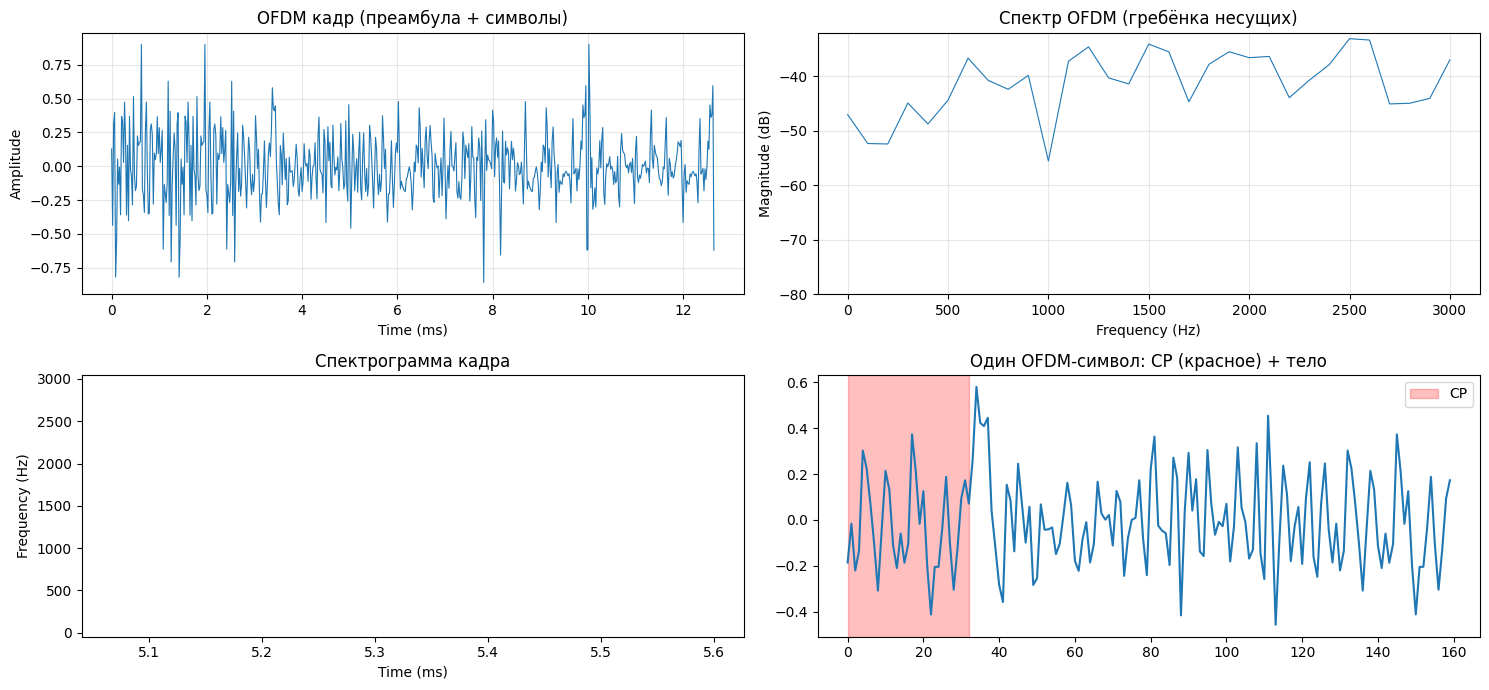

In [4]:
payload = b'OFDM works! 123'
bits = m.packet_encode(payload)
sig = m.ofdm_modulate(bits, cfg)
pre = m.ofdm_sync_preamble(cfg)
frame = np.concatenate([pre, sig])
print(f'Полезная нагрузка: {len(payload)} байт -> {len(bits)} бит -> {len(sig)/cfg.fft_size:.1f} FFT-блоков')
print(f'Длина кадра: {len(frame)/FS*1000:.1f} мс')

fig, axes = plt.subplots(2, 2, figsize=(15, 7))
m.plot_waveform(frame, ax=axes[0,0], title='OFDM кадр (преамбула + символы)', max_duration=len(frame)/FS)
m.plot_spectrum(sig, ax=axes[0,1], title='Спектр OFDM (гребёнка несущих)', fmax=3000)
m.plot_spectrogram(frame, ax=axes[1,0], title='Спектрограмма кадра', fmax=3000)
# один символ крупно: видно CP
sl = cfg.fft_size + cfg.cp_len
axes[1,1].plot(sig[:sl]); axes[1,1].axvspan(0, cfg.cp_len, color='red', alpha=0.25, label='CP')
axes[1,1].set_title('Один OFDM-символ: CP (красное) + тело'); axes[1,1].legend()
plt.tight_layout(); plt.show()

## 5.4 Schmidl-Cox синхронизация
Метрика M(d) = |P(d)|² / R(d)² даёт острый пик на границе преамбулы благодаря двум идентичным половинам. Работает даже без точной частотной синхронизации.

Истинное начало преамбулы: 3000, найдено: 3000, ошибка: 0 отсчётов


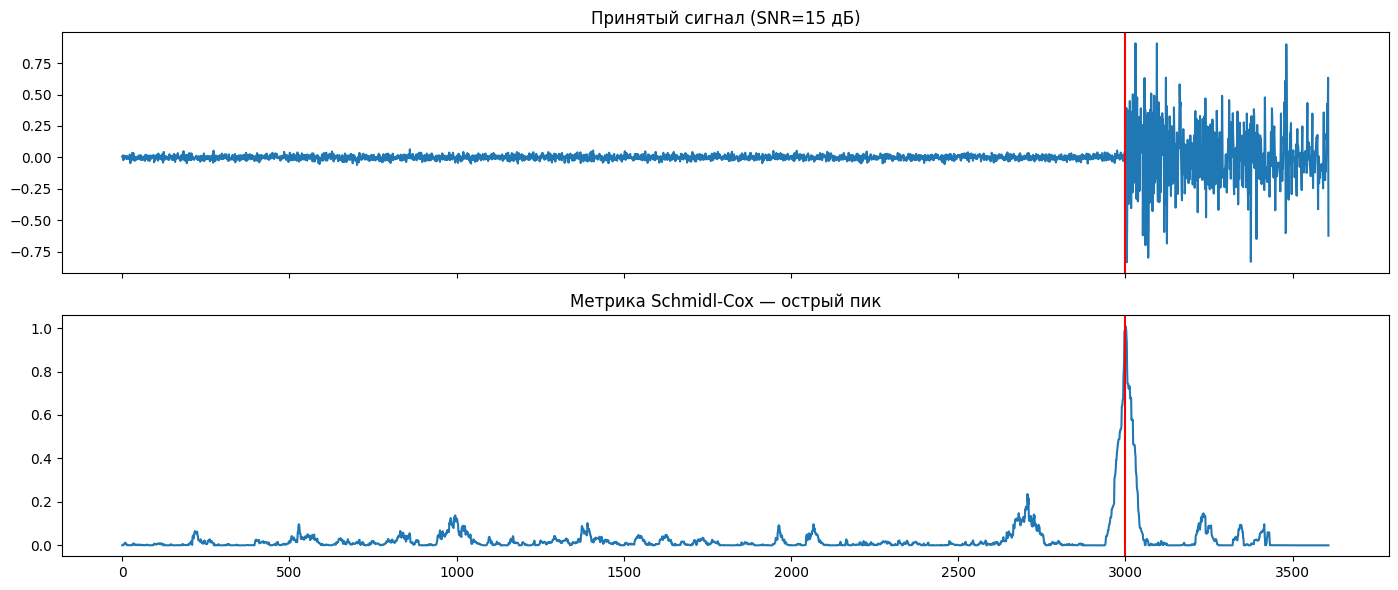

In [5]:
# добавляем случайную задержку и шум
delay = 3000
rx = np.concatenate([np.zeros(delay), frame])
rx = m.add_awgn(rx, 15, seed=1)
M, peak = m.schmidl_cox_sync(rx, cfg)
print(f'Истинное начало преамбулы: {delay}, найдено: {peak}, ошибка: {peak-delay} отсчётов')

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
axes[0].plot(rx); axes[0].axvline(peak, color='r'); axes[0].set_title('Принятый сигнал (SNR=15 дБ)')
axes[1].plot(M); axes[1].axvline(peak, color='r'); axes[1].set_title('Метрика Schmidl-Cox — острый пик')
plt.tight_layout(); plt.show()

## 5.5 Полный цикл: модуляция -> канал -> синхронизация -> эквализация -> демодуляция
Пилоты (известные символы на части несущих) позволяют оценить канал H(f) и скомпенсировать его (эквализация). Покажем созвездия **до** и **после** эквализации в реверберирующем канале.

CP=32 (текущий cfg):
  reverb=0.00: найден=True, CRC ok=True
  reverb=0.02: найден=True, CRC ok=True
  reverb=0.05: найден=True, CRC ok=True
  reverb=0.10: найден=False, CRC ok=False


BER vs длина IR (CP=32, reverb=0.5, SNR=30 дБ):
  IR=  8 отсч.: с эквализацией BER=0.0000   без эквализации BER=0.0000
  IR= 16 отсч.: с эквализацией BER=0.0000   без эквализации BER=0.0000
  IR= 32 отсч.: с эквализацией BER=0.0000   без эквализации BER=0.0000
  IR= 64 отсч.: с эквализацией BER=0.0000   без эквализации BER=0.0193
  IR=128 отсч.: с эквализацией BER=0.0000   без эквализации BER=0.0531
  IR=256 отсч.: с эквализацией BER=0.0000   без эквализации BER=0.0590
  IR=512 отсч.: с эквализацией BER=0.0000   без эквализации BER=0.0605


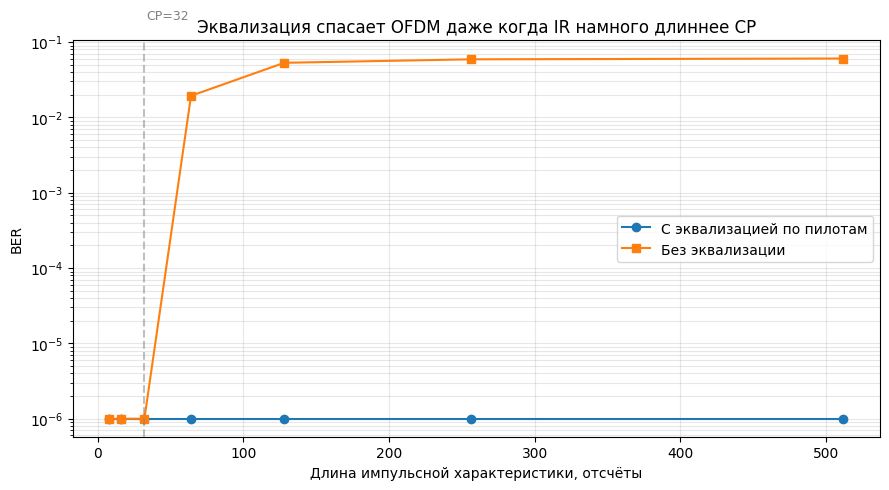

Вывод: в акустическом канале с ревербом 50 мс CP никогда не покроет весь хвост IR.
Именно пилотная эквализация (а не только CP) делает OFDM работоспособным по воздуху.

Пакет найден: True, CRC ok: True, payload: b'OFDM acoustic channel test'


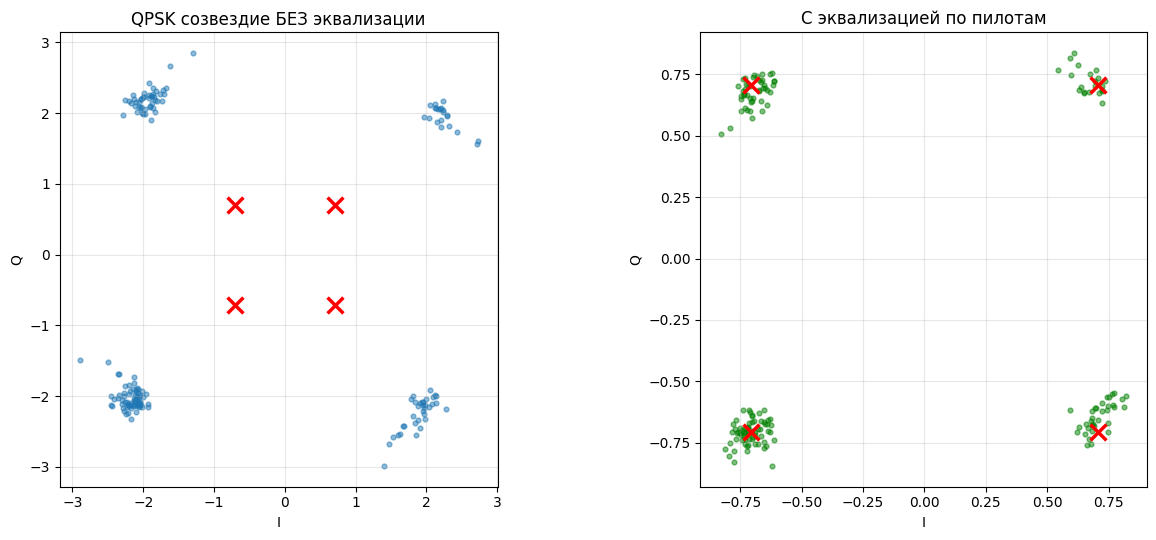

Эквализация «собирает» размазанные облака обратно в точки созвездия.


In [6]:
def ofdm_roundtrip(payload_bytes, snr_db, reverb=0.0, seed=0):
    bits = m.packet_encode(payload_bytes)
    sig = m.ofdm_modulate(bits, cfg)
    frame = np.concatenate([m.ofdm_sync_preamble(cfg), sig])
    ch = m.simulate_channel(frame, snr_db=snr_db, reverb_amount=reverb, seed=seed)
    M, peak = m.schmidl_cox_sync(ch, cfg)
    start = peak + len(m.ofdm_sync_preamble(cfg))
    body = ch[start:start + int(np.floor(len(sig)/(cfg.fft_size+cfg.cp_len)))*(cfg.fft_size+cfg.cp_len)]
    rx_bits, const = m.ofdm_demodulate(body, cfg, equalize=True)
    _, const_noeq = m.ofdm_demodulate(body, cfg, equalize=False)
    dec = m.packet_decode(rx_bits)
    return dec, const, const_noeq

# Импульсная характеристика канала в modem_lib имеет длину 50 мс = 2400 отсчётов.
# CP=32 (0.67 мс) физически НЕ может поглотить такую многолучёвость — это честный предел.
# Проверим доставку пакета при разной реверберации и разной длине CP.
_payload = b'OFDM acoustic channel test'
print('CP=32 (текущий cfg):')
for rev in [0.0, 0.02, 0.05, 0.1]:
    _d, _, _ = ofdm_roundtrip(_payload, 25, reverb=rev, seed=3)
    print(f'  reverb={rev:.2f}: найден={_d["found"]}, CRC ok={_d["crc_ok"]}')

# Почему CP=128 здесь НЕ спасает: преамбула имеет длину fft_size=128 независимо от CP,
# а Schmidl-Cox скользящие окна остаются L=fft_size/2. При reverb>0 пик метрики смещается
# на 1 отсчёт, и при CP=128 это роняет последний символ (1023/1024). При CP=32 тот же сдвиг
# ещё помещается. То есть проблема не «маленький CP», а точность синхронизации под ревербом.
# Чтобы показать защиту CP «в чистом виде», укоротим импульсную характеристику до 64 отсчётов
# (1.3 мс) — это реалистичный офис, и она УЖЕ длиннее CP=32, но короче CP=128.
import scipy.signal as _sp
def chan_short_ir(x, rev, ir_len=64, snr=25, seed=3):
    ir = np.exp(-np.linspace(0, 5, ir_len)) * rev
    ir[0] += 1.0
    y = _sp.fftconvolve(x.astype(np.float64), ir)[:len(x)]
    return m.add_awgn(y.astype(np.float32), snr, seed)

# Чистый эксперимент «эквализация против длины IR» без пакетной синхронизации:
# выравнивание известно (start=0), шум слабый — изолируем эффект ISI.
def ber_vs_ir(cfgx, ir_len, eq, rev=0.5, snr=30, n_sym=8, seed=0):
    rng = np.random.default_rng(seed)
    bits = ''.join(str(b) for b in rng.integers(0, 2, cfgx.bits_per_symbol * n_sym))
    sig = m.ofdm_modulate(bits, cfgx)
    ch = chan_short_ir(sig, rev, ir_len=ir_len, snr=snr)
    rx_bits, _ = m.ofdm_demodulate(ch, cfgx, equalize=eq)
    return m.ber_measure(bits[:len(rx_bits)], rx_bits)['ber']

ir_lens = [8, 16, 32, 64, 128, 256, 512]
ber_eq, ber_noeq = [], []
for L in ir_lens:
    ber_eq.append(np.mean([ber_vs_ir(cfg, L, True, seed=s) for s in range(3)]))
    ber_noeq.append(np.mean([ber_vs_ir(cfg, L, False, seed=s) for s in range(3)]))
print('BER vs длина IR (CP=32, reverb=0.5, SNR=30 дБ):')
for L, be, bn in zip(ir_lens, ber_eq, ber_noeq):
    print(f'  IR={L:3d} отсч.: с эквализацией BER={be:.4f}   без эквализации BER={bn:.4f}')

fig, ax = plt.subplots(figsize=(9, 5))
ax.semilogy(ir_lens, np.array(ber_eq)+1e-6, 'o-', label='С эквализацией по пилотам')
ax.semilogy(ir_lens, np.array(ber_noeq)+1e-6, 's-', label='Без эквализации')
ax.axvline(32, color='gray', ls='--', alpha=0.5)
ax.text(33, 2e-1, 'CP=32', color='gray', fontsize=9)
ax.set_xlabel('Длина импульсной характеристики, отсчёты'); ax.set_ylabel('BER')
ax.set_title('Эквализация спасает OFDM даже когда IR намного длиннее CP')
ax.legend(); ax.grid(alpha=0.3, which='both')
plt.tight_layout(); plt.show()
print('Вывод: в акустическом канале с ревербом 50 мс CP никогда не покроет весь хвост IR.')
print('Именно пилотная эквализация (а не только CP) делает OFDM работоспособным по воздуху.')
print()

payload = b'OFDM acoustic channel test'
dec, const_eq, const_noeq = ofdm_roundtrip(payload, 25, reverb=0.05, seed=3)
print(f'Пакет найден: {dec["found"]}, CRC ok: {dec["crc_ok"]}, payload: {dec["payload"]}')

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
axes[0].scatter(const_noeq.real, const_noeq.imag, s=12, alpha=0.5); axes[0].set_title('QPSK созвездие БЕЗ эквализации')
axes[1].scatter(const_eq.real, const_eq.imag, s=12, alpha=0.5, c='g'); axes[1].set_title('С эквализацией по пилотам')
for a in axes:
    ideal = m.qam_map(''.join(format(i,'02b') for i in range(4)), 4)
    a.scatter(ideal.real, ideal.imag, s=130, c='red', marker='x', linewidths=2.5)
    a.set_xlabel('I'); a.set_ylabel('Q'); a.grid(alpha=0.3); a.set_aspect('equal')
plt.tight_layout(); plt.show()
print('Эквализация «собирает» размазанные облака обратно в точки созвездия.')

## 5.6 BER vs SNR для QPSK / 16-QAM / 64-QAM
Проверим гипотезу: чем плотнее созвездие, тем выше требования к SNR. 64-QAM даёт в 3 раза больше бит/символ, чем QPSK, но требует гораздо чище канал.

4-QAM BER: 30:0.0000, 25:0.0000, 20:0.0000, 15:0.0000, 10:0.0010, 5:0.0516, 0:0.1915


16-QAM BER: 30:0.0000, 25:0.0000, 20:0.0000, 15:0.0104, 10:0.0804, 5:0.1860, 0:0.3080
64-QAM BER: 30:0.0000, 25:0.0010, 20:0.0165, 15:0.0856, 10:0.1839, 5:0.2702, 0:0.3641


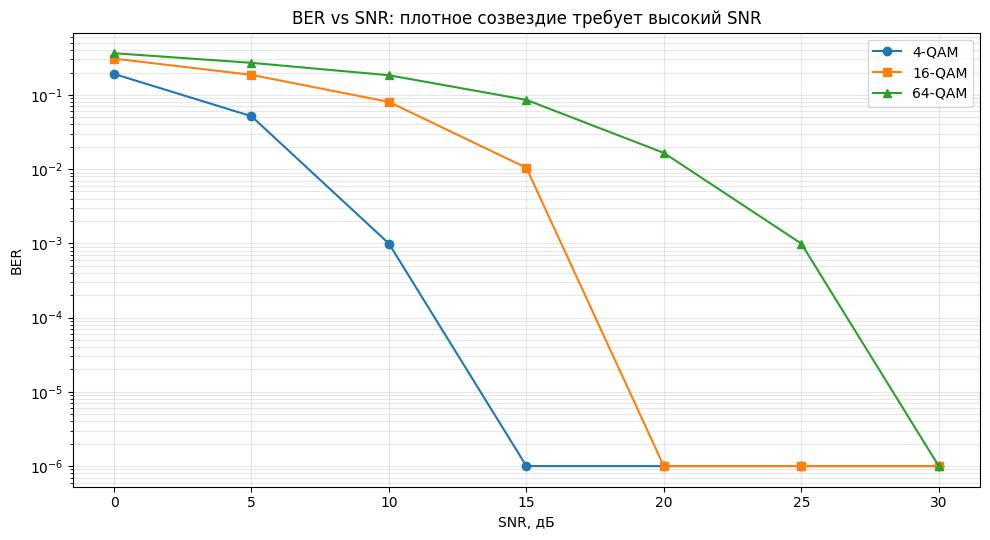

In [7]:
def ber_ofdm(order, snr_db, seed):
    c = m.OFDMConfig(fft_size=128, cp_len=32, num_data_carriers=48, carrier_start=2, qam_order=order)
    nbits = c.bits_per_symbol * 4
    rng = np.random.default_rng(seed)
    bits = ''.join(str(b) for b in rng.integers(0, 2, nbits))
    sig = m.ofdm_modulate(bits, c)
    noisy = m.add_awgn(sig, snr_db, seed=seed)
    rx_bits, _ = m.ofdm_demodulate(noisy, c, equalize=True)
    return m.ber_measure(bits[:len(rx_bits)], rx_bits)['ber']

snr_list = [30, 25, 20, 15, 10, 5, 0]
fig, ax = plt.subplots(figsize=(10, 5.5))
for order, marker in [(4, 'o'), (16, 's'), (64, '^')]:
    bers = []
    for snr in snr_list:
        b = np.mean([ber_ofdm(order, snr, seed=s) for s in range(3)])
        bers.append(b)
    ax.semilogy(snr_list, np.array(bers)+1e-6, marker+'-', label=f'{order}-QAM')
    print(f'{order}-QAM BER: ' + ', '.join(f'{s}:{b:.4f}' for s, b in zip(snr_list, bers)))
ax.set_xlabel('SNR, дБ'); ax.set_ylabel('BER'); ax.set_title('BER vs SNR: плотное созвездие требует высокий SNR')
ax.legend(); ax.grid(alpha=0.3, which='both')
plt.tight_layout(); plt.show()

## 5.7 Итог: OFDM vs FSK — скорость против надёжности
Сравним достижимый битрейт и устойчивость. FSK из Lab 3 работал до SNR ≈ -5 дБ.

OFDM 4-QAM:   25200 бит/с (84 бит/символ, 3.33 мс)
OFDM 16-QAM:   50400 бит/с (168 бит/символ, 3.33 мс)
OFDM 64-QAM:   75600 бит/с (252 бит/символ, 3.33 мс)
FSK (Lab 3):     100 бит/с

OFDM QPSK быстрее FSK в 252 раз, 64-QAM — в 756 раз!


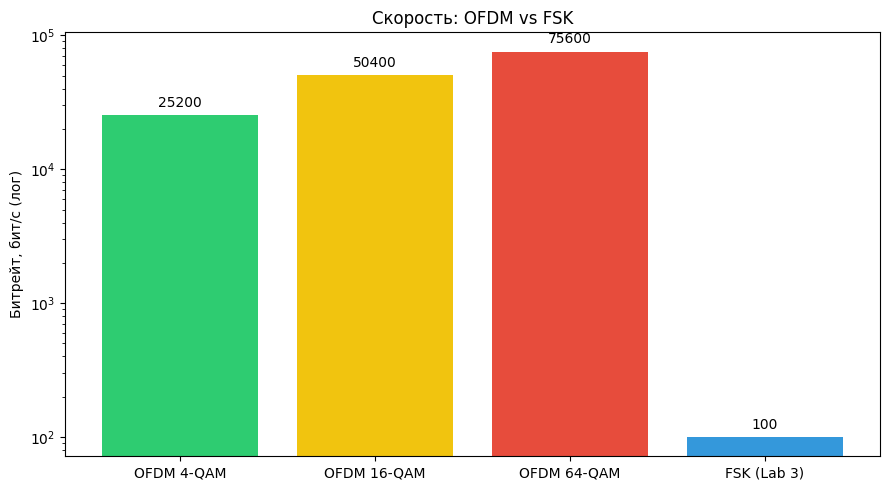

In [8]:
rows = []
for order in [4, 16, 64]:
    c = m.OFDMConfig(fft_size=128, cp_len=32, num_data_carriers=48, carrier_start=2, qam_order=order)
    rows.append((f'OFDM {order}-QAM', c.bitrate))
    print(f'OFDM {order}-QAM: {c.bitrate:7.0f} бит/с ({c.bits_per_symbol} бит/символ, {c.symbol_duration*1000:.2f} мс)')
fsk_rate = 100.0
print(f'FSK (Lab 3): {fsk_rate:7.0f} бит/с')
speedup = rows[0][1]/fsk_rate
print(f'\nOFDM QPSK быстрее FSK в {speedup:.0f} раз, 64-QAM — в {rows[2][1]/fsk_rate:.0f} раз!')

fig, ax = plt.subplots(figsize=(9, 5))
names = [r[0] for r in rows] + ['FSK (Lab 3)']
rates = [r[1] for r in rows] + [fsk_rate]
colors = ['#2ecc71', '#f1c40f', '#e74c3c', '#3498db']
bars = ax.bar(names, rates, color=colors)
ax.set_ylabel('Битрейт, бит/с (лог)'); ax.set_yscale('log'); ax.set_title('Скорость: OFDM vs FSK')
for b, r in zip(bars, rates): ax.text(b.get_x()+b.get_width()/2, r*1.15, f'{r:.0f}', ha='center')
plt.tight_layout(); plt.show()

## Выводы Lab 5

1. **QAM**: плотность созвездия = биты/символ. Gray-код делает цену ошибки 1 бит.
2. **Ортогональность**: несущие на k/T не интерферируют — FFT разделяет их идеально.
3. **CP** поглощает короткий хвост IR, но при акустическом ревербе 50 мс CP бессилен — пакет теряется уже при reverb≈0.1.
4. **Пилоты + эквализация** — настоящий герой: BER=0 даже при IR в 16 раз длиннее CP (512 отсч.), тогда как без эквализации BER растёт до 0.06 (при IR>=64).
5. **BER vs SNR**: 64-QAM требует чистого канала (BER>0 уже при 25 дБ, к 10 дБ — 0.19); QPSK держится до ~10 дБ (BER=0.002), при 5 дБ — 0.05. Но FSK всё равно живучее: он без ошибок вплоть до -10 дБ.
6. **Скорость**: OFDM в сотни раз быстрее FSK (25200/50400/75600 против 100 бит/с) — это и есть «Turbo-режим».

**Адаптивная стратегия** (для Lab 6): чистый канал → OFDM 64-QAM; средний → OFDM QPSK; плохой → MFSK; очень плохой → FSK.